# Calculating Accessibility Using Travel-Time Polygons and Comparing Approaches

**Authors:** Alexander Michels
    
This notebook walks through calculating spatial accessibility using a point-based and areal approach and compares the approaches. We also explore the idea of using the travel-time polygons to create a geography not dependent on adminstrative boundaries for aggregating spatial accessibility measures (Step 2 of 2SFCA). 

**NOTE:** Each "Step 2" takes approximately 5 minutes, so this notebook takes a while.

In [1]:
from collections import Counter
import copy
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from matplotlib.patches import Patch
import pandas as pd
import pathlib
from shapely.ops import unary_union, linemerge, polygonize
from scipy.stats import pearsonr
import seaborn as sns
import tqdm
from typing import List

## Table of Contents

* [Travel-Time Polygons](#ttpolygons)
* [E2SFCA Implementation](#e2sfca)
* [Areal E2SFCA Implementation](#ae2sfca)
* [Data](#data)
* [County Level](#county)
* [Zip Code Level](#zip)
* [Census Tract Level](#tract)
* [Group Block Level](#group)

In [2]:
ilfigsize=(8,12)
sbssize=(20, 14)  # side-by-side size
scattersize=(12, 14)
histsize=(12,6)
cmap = "viridis"
comparecmap = "RdBu"
figpath = "../figures"
output_path = "../outputs"
cbarfont = 18
colorbar_text = "hospital beds per thousand people"
diff_colorbar_text = "E2SFCA minus Areal E2SFCA"
integer_ticks = 6
nullcolor = "grey"
pltdpi = 100
pathlib.Path(figpath).mkdir(parents=True, exist_ok=True)
pathlib.Path(output_path).mkdir(parents=True, exist_ok=True)

<hr id="ttpolygons"/>

# Travel-Time Polygons

Because calculating travel-time polygons can be time-consuming and computationally burdensome, we have supplied driving-time polygons calculated using OpenStreetMap data using OSMnx:

In [3]:
catchment_format = "../data/ttpolygons/resource_catchments_{}distance.geojson"
# distance in travel time (seconds)
distances = [600, 1200, 1800]
projection = "ESRI:102003"
resource = "BEDS"
catchment_id = "ID"

catchments = []
for dist_i, distance in enumerate(distances):
    catchments.append(gpd.read_file(catchment_format.format(distance), driver="GeoJSON"))
    # requires that the resource is a valid value (-999 is null)
    catchments[dist_i] = catchments[dist_i][catchments[dist_i][resource] > 0]
    # requires that the resource isn't nan (not a number)
    catchments[dist_i] = catchments[dist_i].dropna(subset=[resource])
    # we require that the catchments be a polygon or multipolygon (not a point or line, needs to have area!)
    catchments[dist_i] = catchments[dist_i][(catchments[dist_i].geom_type == "Polygon") | (catchments[dist_i].geom_type == "MultiPolygon")]
    # projects the resource!
    catchments[dist_i] = catchments[dist_i].to_crs(projection)
catchments[0].head()

,OBJECTID,ID,NAME,ADDRESS,CITY,STATE,ZIP,ZIP4,TELEPHONE,TYPE,...,WEBSITE,STATE_ID,ALT_NAME,ST_FIPS,OWNER,TTL_STAFF,BEDS,TRAUMA,HELIPAD,geometry
0,1513,0003460644,UHS HARTGROVE HOSPITAL,5730 WEST ROOSEVELT ROAD,CHICAGO,IL,60644,NOT AVAILABLE,(773) 413-1700,PSYCHIATRIC,...,http://www.hartgrovehospital.com,0005454,NOT AVAILABLE,17,PROPRIETARY,-999,128,NOT AVAILABLE,N,"POLYGON ((680612.380 509780.723, 675528.356 50..."
1,1514,0001860612,JESSE BROWN VA MEDICAL CENTER - VA CHICAGO HEA...,820 S DAMEN STREET,CHICAGO,IL,60612,NOT AVAILABLE,(312) 569-8387,MILITARY,...,http://www.chicago.va.gov/,14003F,NOT AVAILABLE,17,GOVERNMENT - FEDERAL,-999,240,NOT AVAILABLE,N,"POLYGON ((685462.211 509236.771, 680281.189 51..."
2,1515,0003160463,PALOS COMMUNITY HOSPITAL,12251 SOUTH 80TH AVENUE,PALOS HEIGHTS,IL,60464,NOT AVAILABLE,(708) 923-4000,GENERAL ACUTE CARE,...,http://www.paloscommunityhospital.org,140062,NOT AVAILABLE,17,NON-PROFIT,-999,377,NOT AVAILABLE,Y,"POLYGON ((678157.519 486927.952, 673323.202 48..."
3,1516,0003660628,ROSELAND COMMUNITY HOSPITAL,45 W 111TH STREET,CHICAGO,IL,60628,NOT AVAILABLE,(773) 995-3000,GENERAL ACUTE CARE,...,http://www.roselandhospital.org,140068,NOT AVAILABLE,17,NON-PROFIT,-999,115,NOT AVAILABLE,N,"POLYGON ((695423.014 490267.854, 695039.134 49..."
4,1517,0002360302,WEST SUBURBAN MEDICAL CENTER,3 ERIE COURT,OAK PARK,IL,60302,NOT AVAILABLE,(708) 383-6200,GENERAL ACUTE CARE,...,http://www.westsuburbanmc.com/Home.aspx,140049,NOT AVAILABLE,17,PROPRIETARY,-999,172,NOT AVAILABLE,N,"POLYGON ((680156.269 513186.258, 676533.665 51..."


Our catchments were calculated on road network data that included a buffer of 10km around Illinois. Let's clip the data to Illinois's extent:

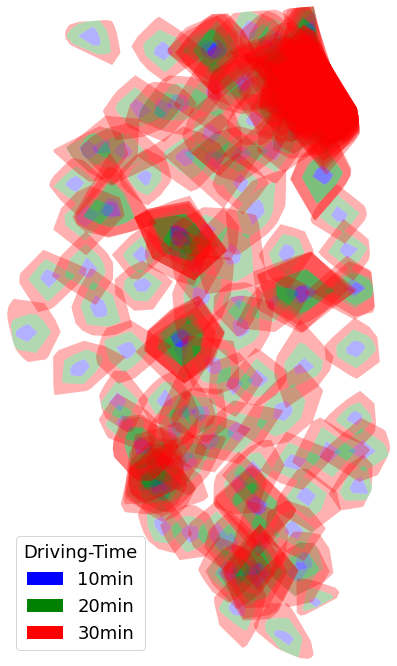

In [4]:
# custom legend:
# https://matplotlib.org/stable/gallery/text_labels_and_annotations/custom_legends.html
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=ilfigsize)
catchments[0].plot(alpha=0.3, ax=ax, facecolor="blue")
catchments[1].plot(alpha=0.3, ax=ax, facecolor="green")
catchments[2].plot(alpha=0.3, ax=ax, facecolor="red")
ax.margins(x=0, y=0)
ax.set_axis_off()
legend_elements = [
    Patch(facecolor="blue", label="10min"),
    Patch(facecolor="green", label="20min"),
    Patch(facecolor="red", label="30min")
                  ]
leg = ax.legend(handles=legend_elements, loc='lower left', fontsize=cbarfont)
leg.set_title(title="Driving-Time", prop={'size': cbarfont})
path = os.path.join(figpath, "IL-ttpoly.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

We can also map the polygons with folium:

In [5]:
m = folium.Map(location=[40, -88], zoom_start=6)
for dist_i, distance in enumerate(distances):
    folium.GeoJson(catchment_format.format(distance)).add_to(m)
m

<AxesSubplot:>

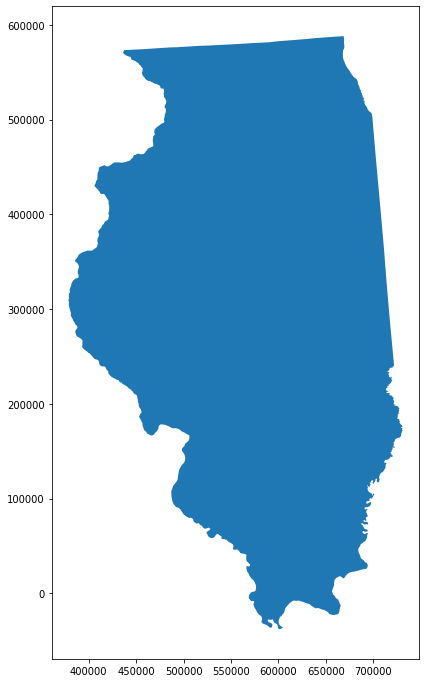

In [6]:
il = gpd.read_file("../data/population/IL-County.shp")
il = il.to_crs(projection)
il = il.dissolve()
il.plot(figsize=ilfigsize)

Let's try to calculate the area of Illinois which is covered by these driving-time catchments. To do this, we:

* calculate the unary union of the dissolved catchments
* put the shape into a GeoDataFrame for convenience
* clip the shape to the spatial extent (Illinois)
* calculate the area, converting from meters squared to kilometers squared
* plot it!

The total area of the travel-time polygons is 131703.22634187492 km^2


<AxesSubplot:>

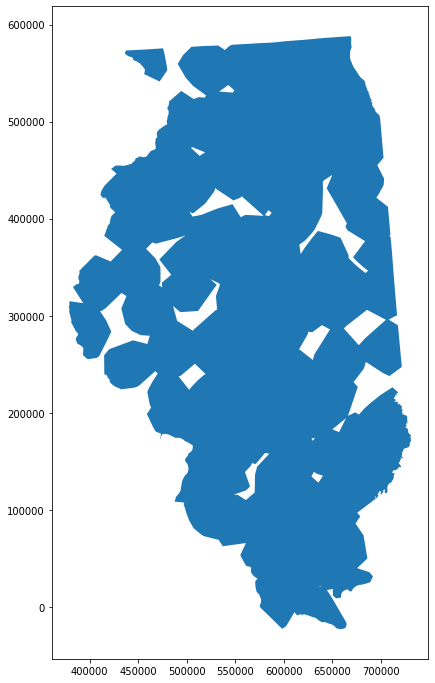

In [7]:
tmp = unary_union([catchments[i].copy(deep=True).dissolve().loc[0, "geometry"] for i in range(3)])
tmp = gpd.GeoDataFrame(geometry=[tmp], crs=projection)
tmp = gpd.clip(tmp, il)
print(f"The total area of the travel-time polygons is {sum(tmp.area) / 1000000} km^2")
tmp.plot(figsize=ilfigsize)

How can we take the list of GeoDataFrames of driving-time polygons and create a geography for reporting our spatial accessibility results?

It's actually pretty simple and can be done with the function below with the following steps:

* First we put all of the shapes into a singular list
* Then we perform a linemerge on the exterior of our shapes. We only need the exterior because the interior (the donut hole part) was created by subtracting other polygons which are already in the list.
* We union the linemerge result and then polygonize the lines to create polygons
* Lastly, we create a GeoDataFrame which is the union of all of the catchments (think dissolve) and only keep the output shapes that intersect with the union.

In [8]:
def catchments_to_output(catchments: List[gpd.GeoDataFrame],
                        spatial_extent: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Creates a GeoDataFrame representing all of the intersections of the catchments.

    Args:
      catchments (List[gpd.GeoDataFrame]): list of GeoDataFrame containing the catchments
      spatial_extent (gpd.GeoDataFrame): GeoDataFrame representing the spatial extent

    Returns:
      GeoDataFrame with shapes representing the intersections of all of the catchments.
    """
    catchment_shapes = [spatial_extent.copy(deep=True).loc[0, "geometry"]]
    for catch_i in range(len(catchments)):
        catchment_shapes.extend(catchments[catch_i]['geometry'].copy(deep=True).to_list())
    catchment_lines = unary_union(linemerge(shape.exterior for shape in catchment_shapes))
    output_polygons = list(polygonize(catchment_lines))
    output_polygons = gpd.GeoSeries(output_polygons).explode(index_parts=False).to_list()
    output_gdf = gpd.GeoDataFrame({'id': range(len(output_polygons)),
                                   'geometry': output_polygons},
                                  crs=catchments[0].crs)
    # clip can produce some multipolygons, so we explode it
    output_gdf = gpd.clip(output_gdf, spatial_extent).explode(index_parts=False)
    return output_gdf[(output_gdf.geom_type == "Polygon")]

In [9]:
agg_gdf = catchments_to_output(catchments, il)

In [10]:
print(f"Type of agg_gdf is: {type(agg_gdf)}")
print(f"The geometries in agg_gdf are of type: {list(set(agg_gdf.geom_type))}")
print(f"The result contains {len(agg_gdf)} shapes")
agg_gdf.head()

Type of agg_gdf is: <class 'geopandas.geodataframe.GeoDataFrame'>
The geometries in agg_gdf are of type: ['Polygon']
The result contains 35817 shapes


,id,geometry
5086,0,"POLYGON ((537011.204 268890.913, 535235.652 26..."
15042,1,"POLYGON ((537011.204 268890.913, 539403.775 26..."
25258,2,"POLYGON ((534100.534 269305.013, 532476.318 27..."
15044,3,"POLYGON ((532476.318 270493.357, 534100.534 26..."
5085,4,"POLYGON ((529617.493 275122.506, 527822.052 27..."


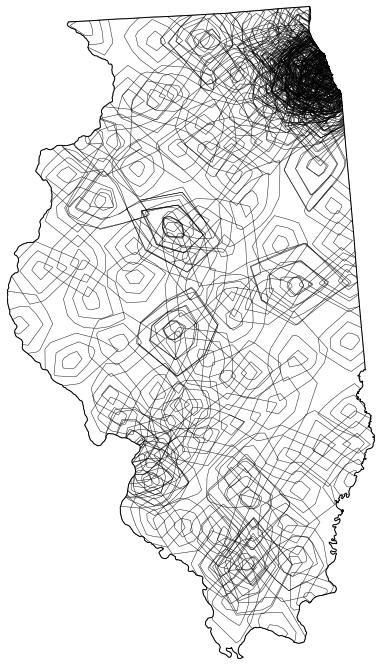

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=ilfigsize)
agg_gdf.plot(ax=ax, alpha=0.5, edgecolor="black", facecolor="none", linewidth=0.5)
ax = il.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.margins(x=0, y=0)
ax.set_axis_off()
path = os.path.join(figpath, "IL-ttpoly2output.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

This gives us a geography that is not dependent on any adminstrative boundaries! Now, we can use it to aggregate our results instead of population!

<hr id="e2sfca"/>

## E2SFCA Implementation

The Enhanced Two-Step Floating Catchment Area method uses two steps to calculate accessibility: (1) calculating resource to population ratios for each resource location (hospital) and (2) aggregating those ratios across space.


First, we define the weights to use for E2SFCA later. Secondly, have a very simple helper function which takes a geodataframe, makes a deep copy of it, and replaces the geometry with the centroids. This is because E2SFCA uses centroids of population data to determine inclusion/exclusion from a catchment.

In [12]:
weights = [1.0, 0.68, 0.22]

In [13]:
def calculate_centroid(geodata):
    """Replaces the geometry in `geodata` with the centroid

    Args:
      geodata: GeoDataFrame

    Returns:
      GeoDataFrame (`geodata`) with geometry replaced by centroids
    """
    centroids = geodata.copy(deep=True)
    centroids["geometry"] = centroids.centroid
    return(centroids)

Next we have a simple function for performing the first step: calcualting resource to population ratios for each hospital. For each travel-time distance (E2SFCA uses 10, 20, and 30 minutes in their initial paper and we do the same here), we calculate which population data centroids fall within each catchment, calculate a weighted sum of the population within each catchment, and divide the resources at each hospital by the weighted sum.

In [14]:
def catchment_ratios_centroid(catchments: List[gpd.GeoDataFrame], write_to: str, catchment_id: str, pop_data: gpd.GeoDataFrame,
                              pop_field: str, resource: gpd.GeoDataFrame, distances: List[float], weights: List[float]) -> List[gpd.GeoDataFrame]:
    """Calculates the resource to population ratios for each catchment using centroids.
    https://doi.org/10.1016/j.healthplace.2009.06.002

    Args:
      catchments (List[gpd.GeoDataFram]): list of GeoDataFrames representing the catchments
      write_to (str): the field to write the ratio to in the catchments GeoDataFrame
      catchment_id (str): ID field for catchment GeoDataFrames
      pop_data (gpd.GeoDataFrame): population GeoDataFrame
      pop_field (str): `pop_data` population field
      resource (str): resource field in catchments GeoDataFrames
      distances (List[float]): list of distances
      weights (List[float]): list of numerical weights where weights[i] applies to distances[i]

    Return:
      List of GeoDataFrames (catchments) with resource to population ratios for each catchment.

    Todo:
        * intersect on just the necessary subset of the columns, i.e pop_data[pop_field, "geometry"]
    """
    pop_data = calculate_centroid(pop_data)
    for dist_i, distance in tqdm.tqdm(enumerate(distances), total=len(distances), desc="Calculating Population:", position=0):
        intersect = gpd.overlay(pop_data.copy(deep=True), catchments[dist_i], how='intersection')
        catchments[dist_i] = catchments[dist_i].join(intersect.groupby(catchment_id)[pop_field].sum(), on=catchment_id, rsuffix='_r')
        catchments[dist_i][pop_field] = catchments[dist_i][pop_field].fillna(value=0)
        catchments[dist_i]["weighted_pop"] = catchments[dist_i][pop_field] * weights[dist_i]
        catchments[dist_i] = catchments[dist_i].drop(columns=[pop_field])
        catchments[dist_i]['time'] = distance
    population_per_resource = Counter()
    for dist_i, distance in enumerate(distances):
        for resource_id, pop in zip(catchments[dist_i][catchment_id], catchments[dist_i]["weighted_pop"]):
            population_per_resource[resource_id] += pop
    population_pd = pd.DataFrame(population_per_resource.items(), columns=[catchment_id, "total_weighted_pop"])
    for dist_i, distance in enumerate(distances):
        catchments[dist_i] = catchments[dist_i].merge(population_pd.copy(), how='left', on=catchment_id)
        catchments[dist_i][write_to] = catchments[dist_i][resource] / catchments[dist_i]["total_weighted_pop"]
        catchments[dist_i] = catchments[dist_i].drop(columns=["total_weighted_pop"])
    return catchments

With that calculated, we aggregate the resource-to-population ratios back to the population geographies:

In [15]:
def aggregate_ratios_centroid(agg_gdf: gpd.GeoDataFrame, agg_id: str, catchments: List[gpd.GeoDataFrame],
                              service_type: str, weights: List[float]) -> gpd.GeoDataFrame:
    """
    Aggregates the accessibility measure by checking if the centroids are within the
    aggregation geometry.

    Args:
      agg_gdf (gpd.GeoDataFrame): GeoDataFrame to aggregate values to
      agg_id (str): ID field for `agg_gdf`
      catchments (List[gpd.GeoDataFrame]): list of GeoDataFrames which contain catchments
      service_type (str): value to aggregate
      weights (List[float]): list of numerical weights where weights[i] corresponds to catchment[i]

    Returns:
      GeoDataFrame (agg_gdf) with aggregated spatial accessibility measures
    """
    service_values = Counter()
    agg_gdf_for_intersect = calculate_centroid(agg_gdf)
    for catch_i in tqdm.tqdm(range(len(catchments)), desc="Calculating Intersections", position=0):
        intersect = gpd.overlay(agg_gdf_for_intersect, catchments[catch_i], how="intersection")
        intersect = intersect.groupby(agg_id)[service_type].sum().reset_index()
        for aid, val in zip(intersect[agg_id], intersect[service_type]):
            service_values[aid] += float(val * weights[catch_i])
    service_pd = pd.DataFrame(service_values.items(), columns=[agg_id, service_type])
    agg_gdf = agg_gdf.merge(service_pd, how='left', on=agg_id)
    return agg_gdf

This is a "wrapper" function which calls the last two functions, combining them into E2SFCA. This version has been altered from the comparison notebook to allow for an aggregation GeoDataFrame other than the population data.

In [16]:
def e2sfca(catchments: List[gpd.GeoDataFrame], write_to: str, catchment_id: str, pop_data: gpd.GeoDataFrame,
           pop_id: str, pop_field: str, resource: str, agg_gdf: gpd.GeoDataFrame, agg_id: str,
           distances: List[float], weights: List[float]) -> gpd.GeoDataFrame:
    """Calculates Enhanced Two-Step Floating Catchment Area (E2SFCA).
    https://doi.org/10.1016/j.healthplace.2009.06.002

    Args:
      catchments (List[gpd.GeoDataFrame]): list of GeoDataFrames representing the catchments
      write_to (str): the field to write the ratio to in the catchments GeoDataFrame
      catchment_id (str): ID field for catchment GeoDataFrames
      pop_data (gpd.GeoDataFrame): population GeoDataFrame
      pop_id (str): `pop_data` ID field
      pop_field (str): `pop_data` population field
      resource (str): resource field in catchments GeoDataFrames
      agg_gdf (gpd.GeoDataFrame): GeoDataFrame to aggregate results to
      agg_id (str): `agg_gdf` ID field
      distances (List[float]): list of distances
      weights (List[float]): list of numerical weights where weights[i] applies to distances[i]

    Return:
      geopandas.GeoDataFrame
    """
    catchments = catchment_ratios_centroid(catchments, write_to, catchment_id, pop_data, pop_field, resource, distances, weights)
    for catch_i in range(len(catchments)):
        # remove infs. Happens if a catchment has no population
        catchments[catch_i] = catchments[catch_i][catchments[catch_i][write_to] != float('inf')]
    return aggregate_ratios_centroid(agg_gdf, agg_id, catchments, write_to, weights)

<hr id="ae2sfca"/>

## Areal E2SFCA Implementation

Similarly, we have an implementation of E2SFCA which uses our areal approach.

Since we aren't using the centroids, we have a helper function which sums attributes proportional the overlap ratio:

In [17]:
def sum_attribute_proportional_to_area(agdf, aid, ogdf, to_sum, weight=1):
    """
    Intersects Geodataframe (agdf) with another Geodataframe (ogdf), multiples the attribute by the percentage of area overlap,
    and calculates weighted sum for agdf grouping by aid field.

    Args:
        agdf (GeoDataFrame): Aggregation GeoDataFrame
        aid (str): agdf ID field which we will group the intersection by
        ogdf (GeoDataFrame): Other GeoDataFrame
        to_sum (str): attribute to sum
        weight (numeric): weight to apply to values

    Returns:
        Counter (dictionary) of aid -> weighted sum
    """
    values = Counter()
    intersect = gpd.overlay(agdf, ogdf, how='intersection', keep_geom_type=False)
    intersect["overlap_pct"] = intersect.area / intersect['area']
    intersect = intersect.dropna(subset=["overlap_pct"])
    intersect.loc[intersect["overlap_pct"] > 1.0, "overlap_pct"] = 1.0  # deals with floating point errors
    intersect[to_sum] = intersect[to_sum] * intersect["overlap_pct"]
    intersect = intersect.groupby(aid)[to_sum].sum().reset_index()
    for aid, val in zip(intersect[aid], intersect[to_sum]):
        values[aid] += float(val * weight)
    return values

We also have a function that calculates resource-to-population ratios using the areal approach:

In [18]:
def catchment_ratios_area(catchments: List[gpd.GeoDataFrame], write_to: str, catchment_id: str, pop_data: gpd.GeoDataFrame,
                          pop_field: str, resource: gpd.GeoDataFrame, distances: List[float], weights: List[float]) -> List[gpd.GeoDataFrame]:
    """Calculates the resource to population ratios for each catchment using proportion of intersect
    https://doi.org/10.1016/j.healthplace.2009.06.002

    Args:
      catchments (List[gpd.GeoDataFram]): list of GeoDataFrames representing the catchments
      write_to (str): the field to write the ratio to in the catchments GeoDataFrame
      catchment_id (str): ID field for catchment GeoDataFrames
      pop_data (gpd.GeoDataFrame): population GeoDataFrame
      pop_field (str): `pop_data` population field
      resource (str): resource field in catchments GeoDataFrames
      distances (List[float]): list of distances
      weights (List[float]): list of numerical weights where weights[i] applies to distances[i]

    Return:
      List of GeoDataFrames (catchments) with resource to population ratios for each catchment.
    """
    pop_data["area"] = pop_data.area
    for dist_i, distance in tqdm.tqdm(enumerate(distances), total=len(distances), desc="Calculating Population:", position=0):
        intersect = gpd.overlay(pop_data.copy(deep=True), catchments[dist_i], how='intersection', keep_geom_type=False)
        intersect["overlap_pct"] = intersect.area / intersect["area"]
        intersect = intersect.dropna(subset=["overlap_pct"])
        intersect.loc[intersect["overlap_pct"] > 1.0, "overlap_pct"] = 1.0  # deals with floating point errors
        intersect[pop_field] = intersect[pop_field] * intersect["overlap_pct"]
        catchments[dist_i] = catchments[dist_i].join(intersect.groupby(catchment_id)[pop_field].sum(), on=catchment_id, rsuffix='_r')
        catchments[dist_i][pop_field] = catchments[dist_i][pop_field].fillna(value=0)
        catchments[dist_i]["weighted_pop"] = catchments[dist_i][pop_field] * weights[dist_i]
        catchments[dist_i] = catchments[dist_i].drop(columns=[pop_field])
        catchments[dist_i]['time'] = distance
    population_per_resource = Counter()
    for dist_i, distance in enumerate(distances):
        for resource_id, pop in zip(catchments[dist_i][catchment_id], catchments[dist_i]["weighted_pop"]):
            population_per_resource[resource_id] += pop
    population_pd = pd.DataFrame(population_per_resource.items(), columns=[catchment_id, "total_weighted_pop"])
    for dist_i, distance in enumerate(distances):
        catchments[dist_i] = catchments[dist_i].merge(population_pd.copy(), how='left', on=catchment_id)
        catchments[dist_i][write_to] = catchments[dist_i][resource] / catchments[dist_i]["total_weighted_pop"]
        catchments[dist_i] = catchments[dist_i].drop(columns=["total_weighted_pop"])
    return catchments

To aggregate the ratios across space, we have an areal version of E2SFCA second step.

In [19]:
def aggregate_ratios_area(agg_gdf: gpd.GeoDataFrame, agg_id: str, catchments: List[gpd.GeoDataFrame],
                          service_type: str, weights: List[float]) -> gpd.GeoDataFrame:
    """
    Aggregates the accessibility measure to the using percentage of area overlap.

    Args:
      agg_gdf (gpd.GeoDataFrame): GeoDataFrame to aggregate values to
      agg_id (str): ID field for `agg_gdf`
      catchments (List[gpd.GeoDataFrame]): list of GeoDataFrames which contain catchments
      service_type (str): value to aggregate
      weights (List[float]): list of numerical weights where weights[i] corresponds to catchment[i]

    Returns:
      GeoDataFrame (agg_gdf) with aggregated spatial accessibility measures
    """
    service_values = Counter()
    agg_gdf["area"] = agg_gdf.area
    for catch_i in tqdm.tqdm(range(len(catchments)), desc="Calculating Intersections", position=0):
        service_values += sum_attribute_proportional_to_area(agg_gdf, agg_id, catchments[catch_i], service_type, weights[catch_i])
    service_pd = pd.DataFrame(service_values.items(), columns=[agg_id, service_type])
    agg_gdf = agg_gdf.merge(service_pd, how='left', on=agg_id)
    return agg_gdf

And for simplicity, we again have a wrapper function. This version has been altered from the comparison notebook to allow for an aggregation GeoDataFrame other than the population data.

In [20]:
def ae2sfca(catchments: List[gpd.GeoDataFrame], write_to: str, catchment_id: str, pop_data: gpd.GeoDataFrame,
            pop_id: str, pop_field: str, resource: str, agg_gdf: gpd.GeoDataFrame, agg_id: str,
            distances: List[float], weights: List[float]) -> gpd.GeoDataFrame:
    """Calculates Enhanced Two-Step Floating Catchment Area (E2SFCA).
    https://doi.org/10.1016/j.healthplace.2009.06.002

    Args:
      catchments (List[gpd.GeoDataFrame]): list of GeoDataFrames representing the catchments
      write_to (str): the field to write the ratio to in the catchments GeoDataFrame
      catchment_id (str): ID field for catchment GeoDataFrames
      pop_data (gpd.GeoDataFrame): population GeoDataFrame
      pop_id (str): `pop_data` ID field
      pop_field (str): `pop_data` population field
      resource (str): resource field in catchments GeoDataFrames
      agg_gdf (gpd.GeoDataFrame): GeoDataFrame to aggregate results to
      agg_id (str): `agg_gdf` ID field
      distances (List[float]): list of distances
      weights (List[float]): list of numerical weights where weights[i] applies to distances[i]

    Return:
      geopandas.GeoDataFrame
    """
    catchments = catchment_ratios_area(catchments, write_to, catchment_id, pop_data, pop_field, resource, distances, weights)
    for catch_i in range(len(catchments)):
        # remove infs, happens if a catchment has no population
        catchments[catch_i] = catchments[catch_i][catchments[catch_i][write_to] != float('inf')]
    return aggregate_ratios_area(agg_gdf, agg_id, catchments, write_to, weights)

<hr id="county"/>

# County Level

Now we can grab the population data at the county level!

In [21]:
county_pop = gpd.read_file("../data/population/IL-County.shp")
print(len(county_pop))
county_pop = county_pop.to_crs(projection)
county_pop.head()

102


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,TOTPOP,geometry
0,17,161,00424282,0500000US17161,17161,Rock Island,06,1107097990,61745666,143873.0,"POLYGON ((409096.626 440162.408, 409093.696 44..."
1,17,007,00424205,0500000US17007,17007,Boone,06,727180620,3363818,53537.0,"POLYGON ((578203.213 552318.923, 578115.215 55..."
2,17,027,00424215,0500000US17027,17027,Clinton,06,1227502416,75634004,37634.0,"POLYGON ((542119.695 147412.781, 543763.063 14..."
3,17,003,00424203,0500000US17003,17003,Alexander,06,609667772,44539209,6260.0,"POLYGON ((568769.530 -4202.705, 568798.266 -39..."
4,17,189,01785150,0500000US17189,17189,Washington,06,1457093517,3412705,14058.0,"POLYGON ((544127.473 120671.414, 544273.213 12..."


Let's plot the population per county:

<AxesSubplot:>

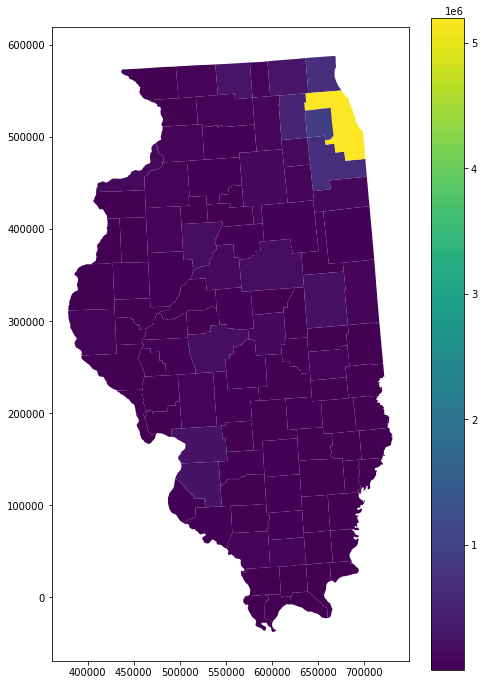

In [22]:
county_pop.plot(column="TOTPOP", figsize=ilfigsize, legend=True)

Let's dissolve Illinois to get a nice outline in case we need it for plotting!

<AxesSubplot:>

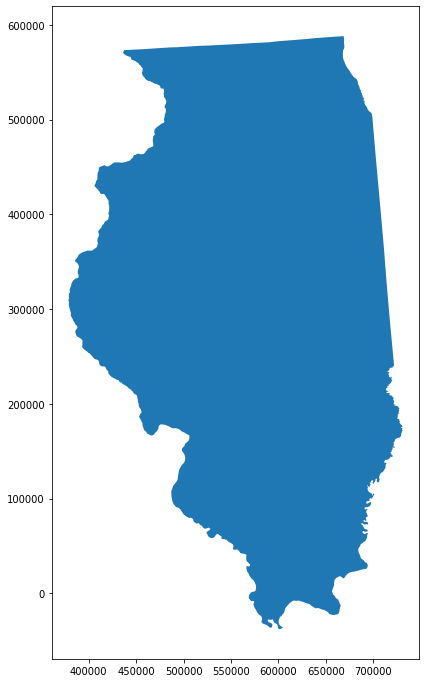

In [23]:
il = county_pop.copy(deep=True)
il = il.dissolve()
il.plot(figsize=ilfigsize)

Now let's calculate and plot E2SFCA:

In [24]:
e2sfca_county = e2sfca(catchments,
                       "e2sfca",
                       catchment_id, 
                       county_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
e2sfca_county["e2sfca"] = e2sfca_county["e2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [02:25<00:00, 48.45s/it]


In [25]:
e2sfca_county.to_file(os.path.join(output_path, "e2sfca-county-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


<AxesSubplot:>

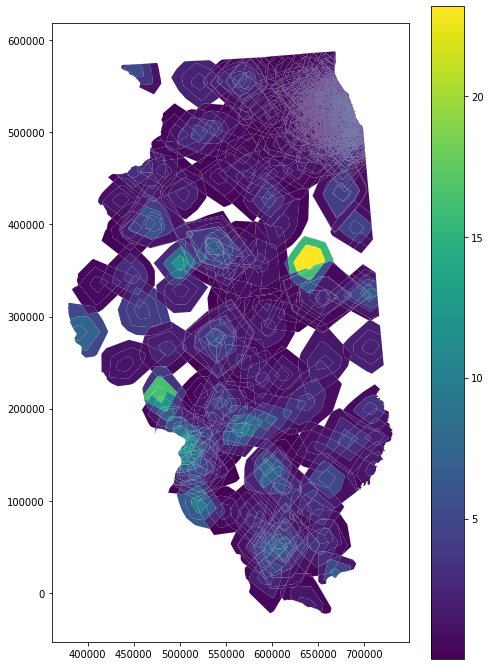

In [26]:
e2sfca_county.plot(column="e2sfca", figsize=ilfigsize, legend=True)

In [27]:
ae2sfca_county = ae2sfca(catchments,
                       "ae2sfca",
                       catchment_id, 
                       county_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
ae2sfca_county["ae2sfca"] = ae2sfca_county["ae2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [04:39<00:00, 93.25s/it]


In [28]:
ae2sfca_county.to_file(os.path.join(output_path, "ae2sfca-county-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


Similarly, we can calculate the Areal E2SFCA and plot it:

<AxesSubplot:>

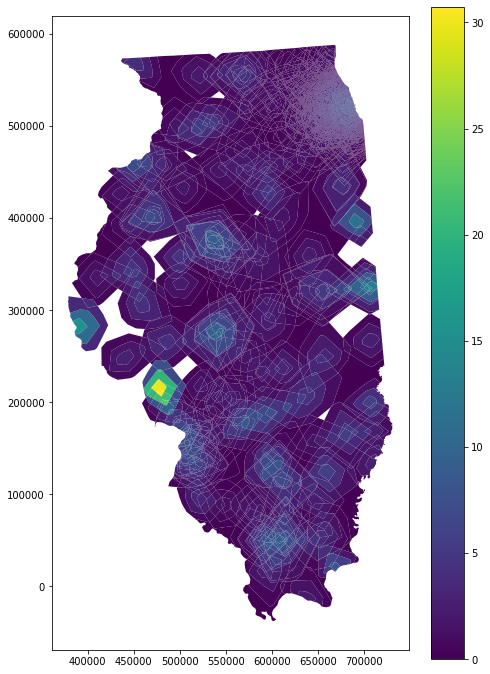

In [29]:
ae2sfca_county.plot(column="ae2sfca", figsize=ilfigsize, legend=True)

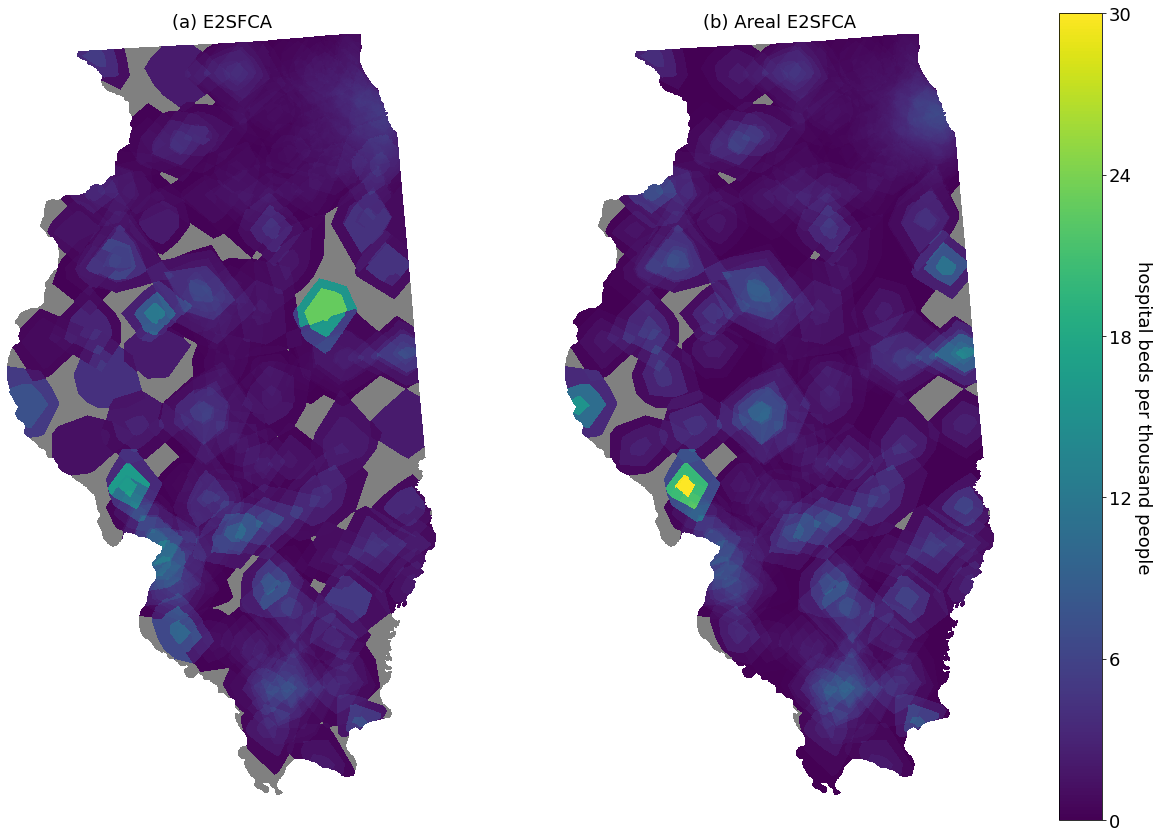

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=sbssize)
vmin = min(np.nanmin(e2sfca_county["e2sfca"]), np.nanmin(ae2sfca_county["ae2sfca"]))
vmax = max(np.nanmax(e2sfca_county["e2sfca"]), np.nanmax(ae2sfca_county["ae2sfca"]))
tick_spacing = round(int(vmax - vmin) / (integer_ticks - 1))
ticks = list(range(math.floor(vmin), math.ceil(vmax) + 1, tick_spacing))
vmin, vmax = min(ticks), max(ticks)
axes[0] = e2sfca_county.plot(column="e2sfca", ax=axes[0], antialiased=False, cmap=cmap,
                             edgecolor="none", missing_kwds=dict(color=nullcolor),
                             vmin=vmin, vmax=vmax)
axes[0].set_title("(a) E2SFCA", fontsize=cbarfont)
axes[1] = ae2sfca_county.plot(column="ae2sfca", ax=axes[1], antialiased=False, cmap=cmap,
                              edgecolor="none", missing_kwds=dict(color=nullcolor),
                              vmin=vmin, vmax=vmax)
axes[1].set_title("(b) Areal E2SFCA", fontsize=cbarfont)

# add colorbar axes
plt.subplots_adjust(wspace=0, hspace=0)
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.9, 0.1, 0.03, 0.8])
cax.tick_params(labelsize=cbarfont)
# create colormap
colorbarsm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
colorbarsm._A = []
# convert ticks to integers
colorbar = fig.colorbar(colorbarsm, cax=cax, ticks=ticks)
ticklabels = [str(tick) for tick in ticks]
# add >= or <= if necessary
if ticks[0] > vmin:
    ticklabels[0] = r"$\leq${}".format(ticklabels[0])
if ticks[-1] < vmax:
    ticklabels[-1] = r"$\geq${}".format(ticklabels[-1])
colorbar.ax.set_yticklabels(ticklabels)
colorbar.set_label(colorbar_text, fontsize=cbarfont, labelpad=20, rotation=270)
for ax in axes:
    ax.margins(x=0, y=0)
    ax.set_axis_off()
path = os.path.join(figpath, "IL-county-ttpolygons.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Areal E2SFCA')

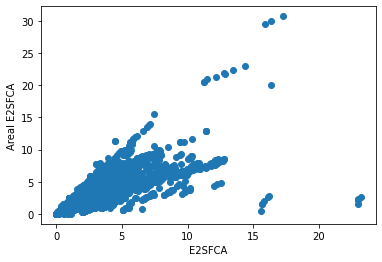

In [31]:
# 0 is left as nan for plotting purposes, but for scatter, we want to fill it in
e2sfca_county["e2sfca"] = e2sfca_county["e2sfca"].fillna(value=0)
ae2sfca_county["ae2sfca"] = ae2sfca_county["ae2sfca"].fillna(value=0)
plt.scatter(e2sfca_county["e2sfca"], ae2sfca_county["ae2sfca"])
plt.xlabel("E2SFCA")
plt.ylabel("Areal E2SFCA")

In [32]:
r, p = pearsonr(e2sfca_county["e2sfca"], ae2sfca_county["ae2sfca"])
print(f"The Pearon's R is {r:0.3f} with a two-tailed p-value of {p}")

The Pearon's R is 0.803 with a two-tailed p-value of 0.0


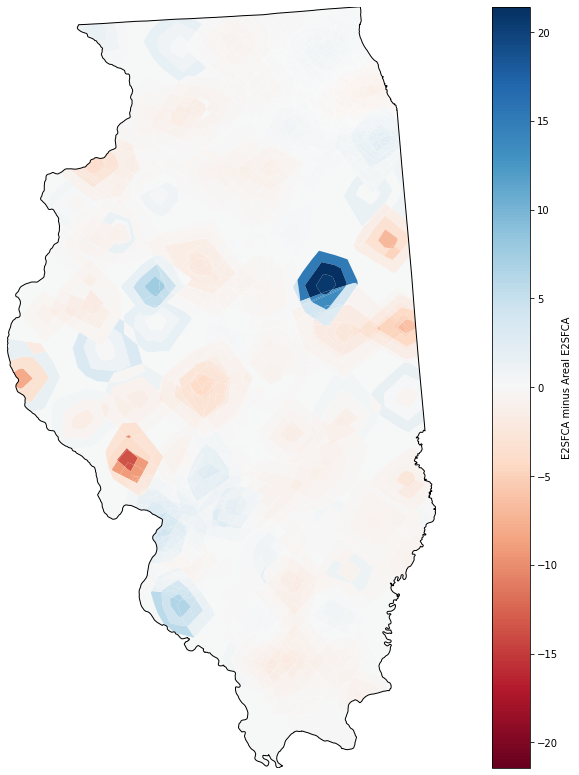

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=sbssize)
county_diff = agg_gdf.copy(deep=True)
county_diff["diff"] = np.asarray(e2sfca_county["e2sfca"]) - np.asarray(ae2sfca_county["ae2sfca"])
_min, _max = np.nanmin(county_diff["diff"]), np.nanmax(county_diff["diff"])
# get 'largest' value by absolute value to center our legend around zero
max_mag = max(abs(_min), abs(_max))
ax = county_diff.plot(ax=ax, column="diff", figsize=ilfigsize, legend=True, cmap=comparecmap,
                    vmin=-max_mag, vmax=max_mag,
                    legend_kwds={'label': diff_colorbar_text})
ax = il.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.margins(x=0, y=0)
ax.set_axis_off()
path = os.path.join(figpath, "IL-county-diff-ttpoly.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

<hr id="zip"/>

# Zip Code

Now we can grab the population data at the zip code level!

In [34]:
zip_pop = gpd.read_file("../data/population/IL-Zip.shp")
print(len(zip_pop))
zip_pop = zip_pop.to_crs(projection)
zip_pop.head()

1383


,ZCTA5CE10,AFFGEOID10,GEOID10,ALAND10,AWATER10,TOTPOP,geometry
0,62861,8600000US62861,62861,1409142,545032,166.0,"POLYGON ((690353.479 89210.648, 691068.854 892..."
1,61340,8600000US61340,61340,1324366,0,263.0,"MULTIPOLYGON (((560512.383 442119.579, 560618...."
2,62966,8600000US62966,62966,293185857,7982891,15049.0,"POLYGON ((570670.586 51528.300, 570994.260 516..."
3,61320,8600000US61320,61320,2425411,0,681.0,"POLYGON ((565468.094 453292.844, 566946.290 45..."
4,62848,8600000US62848,62848,8480283,15823,692.0,"POLYGON ((588956.010 127210.283, 588902.551 12..."


Let's plot the population per county:

<AxesSubplot:>

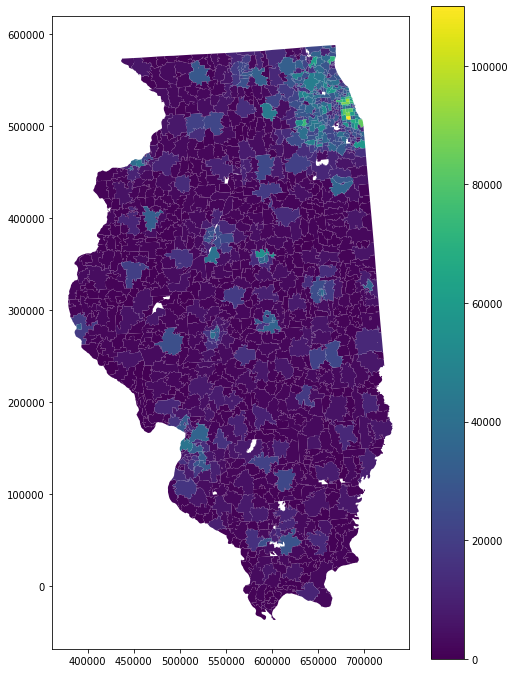

In [35]:
zip_pop.plot(column="TOTPOP", figsize=ilfigsize, legend=True)

Now let's calculate and plot E2SFCA:

In [36]:
e2sfca_zip = e2sfca(catchments,
                       "e2sfca",
                       catchment_id, 
                       zip_pop,
                       "ZCTA5CE10",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
e2sfca_zip["e2sfca"] = e2sfca_zip["e2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [02:22<00:00, 47.55s/it]


In [37]:
e2sfca_zip.to_file(os.path.join(output_path, "e2sfca-zip-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


<AxesSubplot:>

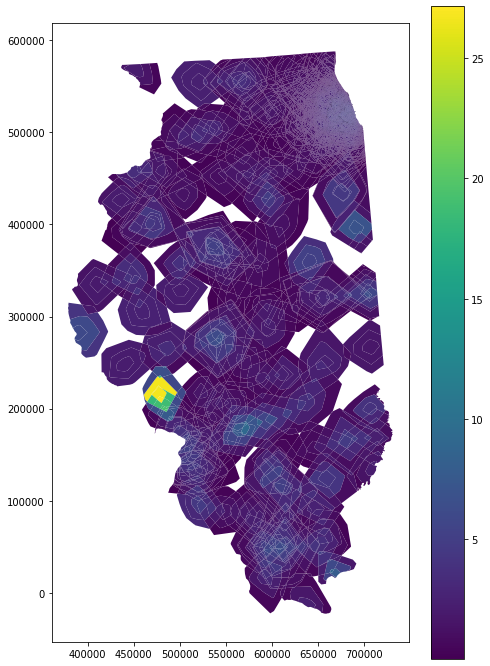

In [38]:
e2sfca_zip.plot(column="e2sfca", figsize=ilfigsize, legend=True)

In [39]:
ae2sfca_zip = ae2sfca(catchments,
                       "ae2sfca",
                       catchment_id, 
                       zip_pop,
                       "ZCTA5CE10",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
ae2sfca_zip["ae2sfca"] = ae2sfca_zip["ae2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [04:29<00:00, 89.95s/it]


In [40]:
ae2sfca_county.to_file(os.path.join(output_path, "ae2sfca-zip-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


Similarly, we can calculate the Areal E2SFCA and plot it:

<AxesSubplot:>

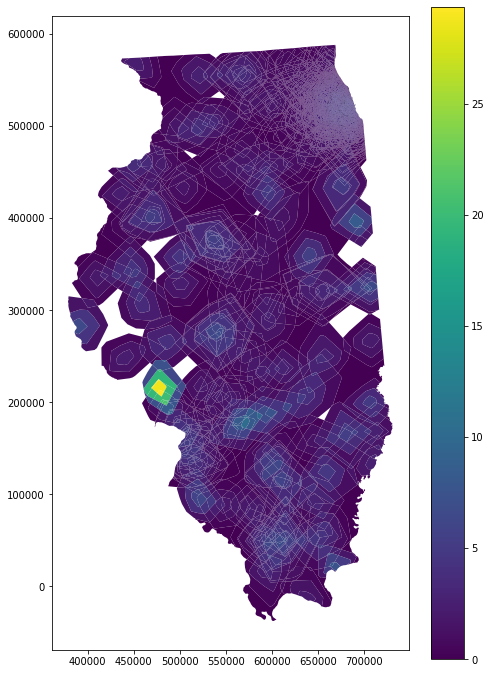

In [41]:
ae2sfca_zip.plot(column="ae2sfca", figsize=ilfigsize, legend=True)

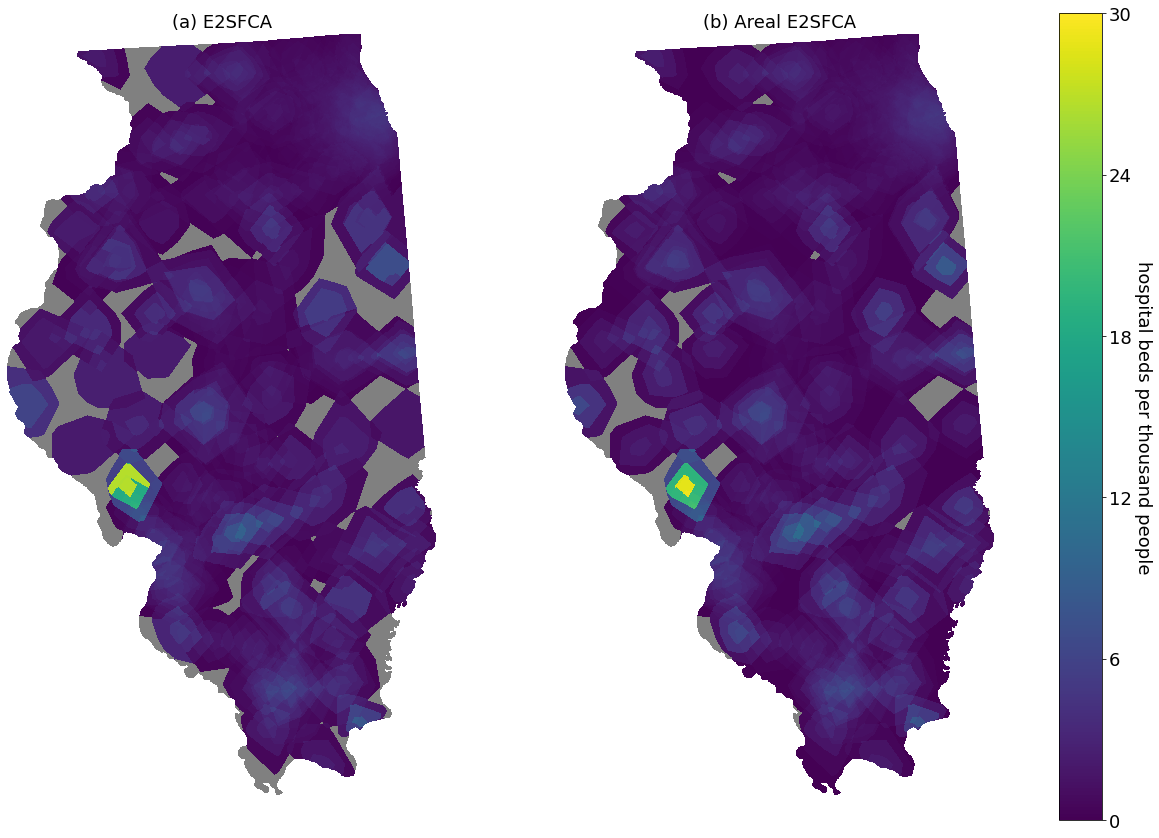

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=sbssize)
vmin = min(np.nanmin(e2sfca_zip["e2sfca"]), np.nanmin(ae2sfca_zip["ae2sfca"]))
vmax = max(np.nanmax(e2sfca_zip["e2sfca"]), np.nanmax(ae2sfca_zip["ae2sfca"]))
tick_spacing = round(int(vmax - vmin) / (integer_ticks - 1))
ticks = list(range(math.floor(vmin), math.ceil(vmax) + 1, tick_spacing))
vmin, vmax = min(ticks), max(ticks)
axes[0] = e2sfca_zip.plot(column="e2sfca", ax=axes[0], antialiased=False, cmap=cmap,
                             edgecolor="none", missing_kwds=dict(color=nullcolor),
                             vmin=vmin, vmax=vmax)
axes[0].set_title("(a) E2SFCA", fontsize=cbarfont)
axes[1] = ae2sfca_zip.plot(column="ae2sfca", ax=axes[1], antialiased=False, cmap=cmap,
                              edgecolor="none", missing_kwds=dict(color=nullcolor),
                              vmin=vmin, vmax=vmax)
axes[1].set_title("(b) Areal E2SFCA", fontsize=cbarfont)

# add colorbar axes
plt.subplots_adjust(wspace=0, hspace=0)
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.9, 0.1, 0.03, 0.8])
cax.tick_params(labelsize=cbarfont)
# create colormap
colorbarsm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
colorbarsm._A = []
# convert ticks to integers
colorbar = fig.colorbar(colorbarsm, cax=cax, ticks=ticks)
ticklabels = [str(tick) for tick in ticks]
# add >= or <= if necessary
if ticks[0] > vmin:
    ticklabels[0] = r"$\leq${}".format(ticklabels[0])
if ticks[-1] < vmax:
    ticklabels[-1] = r"$\geq${}".format(ticklabels[-1])
colorbar.ax.set_yticklabels(ticklabels)
colorbar.set_label(colorbar_text, fontsize=cbarfont, labelpad=20, rotation=270)
for ax in axes:
    ax.margins(x=0, y=0)
    ax.set_axis_off()
path = os.path.join(figpath, "IL-zip-ttpolygons.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Areal E2SFCA')

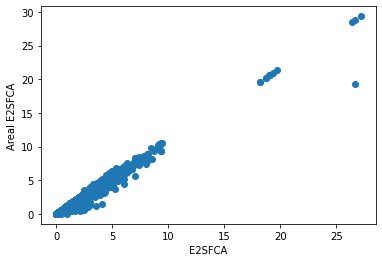

In [43]:
# 0 is left as nan for plotting purposes, but for scatter, we want to fill it in
e2sfca_zip["e2sfca"] = e2sfca_zip["e2sfca"].fillna(value=0)
ae2sfca_zip["ae2sfca"] = ae2sfca_zip["ae2sfca"].fillna(value=0)
plt.scatter(e2sfca_zip["e2sfca"], ae2sfca_zip["ae2sfca"])
plt.xlabel("E2SFCA")
plt.ylabel("Areal E2SFCA")

In [44]:
r, p = pearsonr(e2sfca_zip["e2sfca"], ae2sfca_zip["ae2sfca"])
print(f"The Pearon's R is {r:0.3f} with a two-tailed p-value of {p}")

The Pearon's R is 0.996 with a two-tailed p-value of 0.0


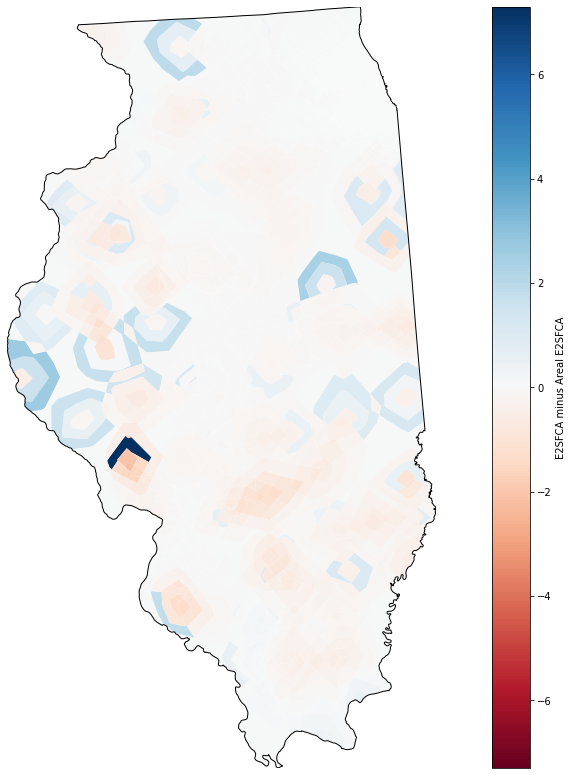

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=sbssize)
zip_diff = agg_gdf.copy(deep=True)
zip_diff["diff"] = np.asarray(e2sfca_zip["e2sfca"]) - np.asarray(ae2sfca_zip["ae2sfca"])
_min, _max = np.nanmin(zip_diff["diff"]), np.nanmax(zip_diff["diff"])
# get 'largest' value by absolute value to center our legend around zero
max_mag = max(abs(_min), abs(_max))
ax = zip_diff.plot(ax=ax, column="diff", figsize=ilfigsize, legend=True, cmap=comparecmap,
                    vmin=-max_mag, vmax=max_mag,
                    legend_kwds={'label': diff_colorbar_text})
ax = il.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.margins(x=0, y=0)
ax.set_axis_off()
path = os.path.join(figpath, "IL-zip-diff-ttpoly.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

<hr id="tract"/>

# Census Tract

Now we can grab the population data at the census tract level!

In [46]:
tract_pop = gpd.read_file("../data/population/IL-Tract.shp")
tract_pop = tract_pop.to_crs(projection)
tract_pop.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,TOTPOP,geometry
0,17,031,807500,1400000US17031807500,17031807500,8075,CT,988887,0,3358.0,"POLYGON ((678981.148 536613.217, 678967.750 53..."
1,17,031,440300,1400000US17031440300,17031440300,4403,CT,1295106,0,4706.0,"POLYGON ((690577.917 506714.601, 690837.329 50..."
2,17,197,883209,1400000US17197883209,17197883209,8832.09,CT,2581912,0,3025.0,"POLYGON ((646694.279 480482.983, 647339.204 48..."
3,17,057,952800,1400000US17057952800,17057952800,9528,CT,10988110,13105,2591.0,"POLYGON ((499528.298 375732.169, 501917.346 37..."
4,17,117,957200,1400000US17117957200,17117957200,9572,CT,7447622,75028,4963.0,"POLYGON ((531041.854 188693.839, 531161.287 18..."


Let's plot the population per county:

<AxesSubplot:>

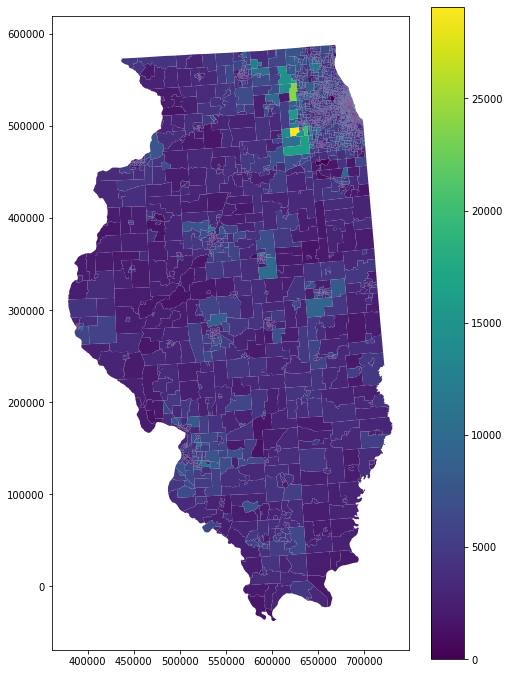

In [47]:
tract_pop.plot(column="TOTPOP", figsize=ilfigsize, legend=True)

Now let's calculate and plot E2SFCA:

In [48]:
e2sfca_tract = e2sfca(catchments,
                       "e2sfca",
                       catchment_id, 
                       tract_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
e2sfca_tract["e2sfca"] = e2sfca_tract["e2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [02:16<00:00, 45.38s/it]


In [49]:
e2sfca_tract.to_file(os.path.join(output_path, "e2sfca-tract-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


<AxesSubplot:>

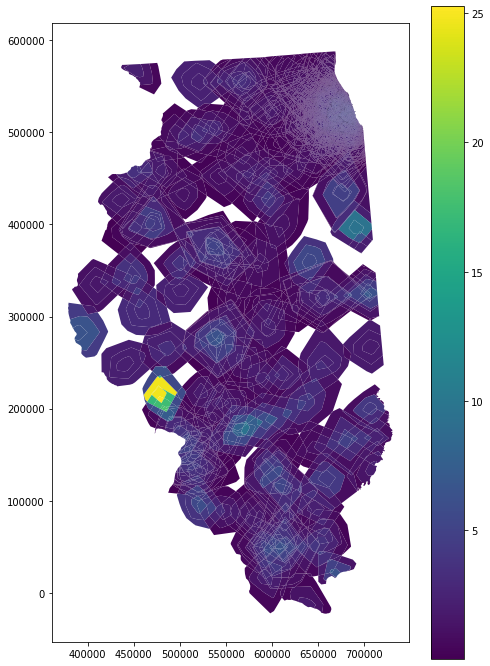

In [50]:
e2sfca_tract.plot(column="e2sfca", figsize=ilfigsize, legend=True)

In [51]:
ae2sfca_tract = ae2sfca(catchments,
                       "ae2sfca",
                       catchment_id, 
                       tract_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
ae2sfca_tract["ae2sfca"] = ae2sfca_tract["ae2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [04:12<00:00, 84.28s/it]


In [52]:
ae2sfca_county.to_file(os.path.join(output_path, "ae2sfca-tract-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


Similarly, we can calculate the Areal E2SFCA and plot it:

<AxesSubplot:>

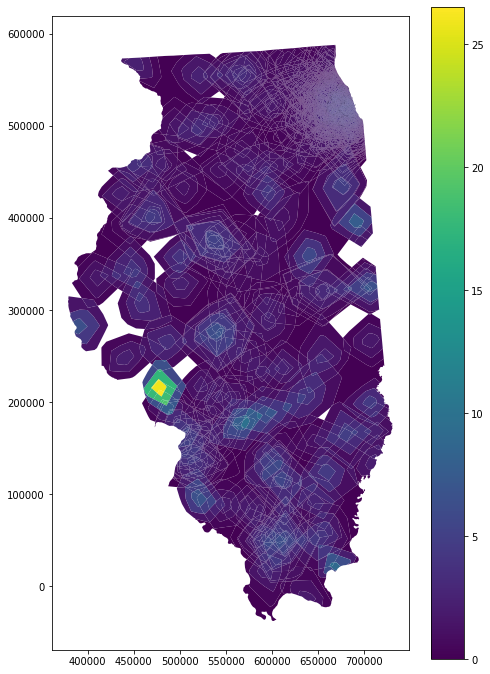

In [53]:
ae2sfca_tract.plot(column="ae2sfca", figsize=ilfigsize, legend=True)

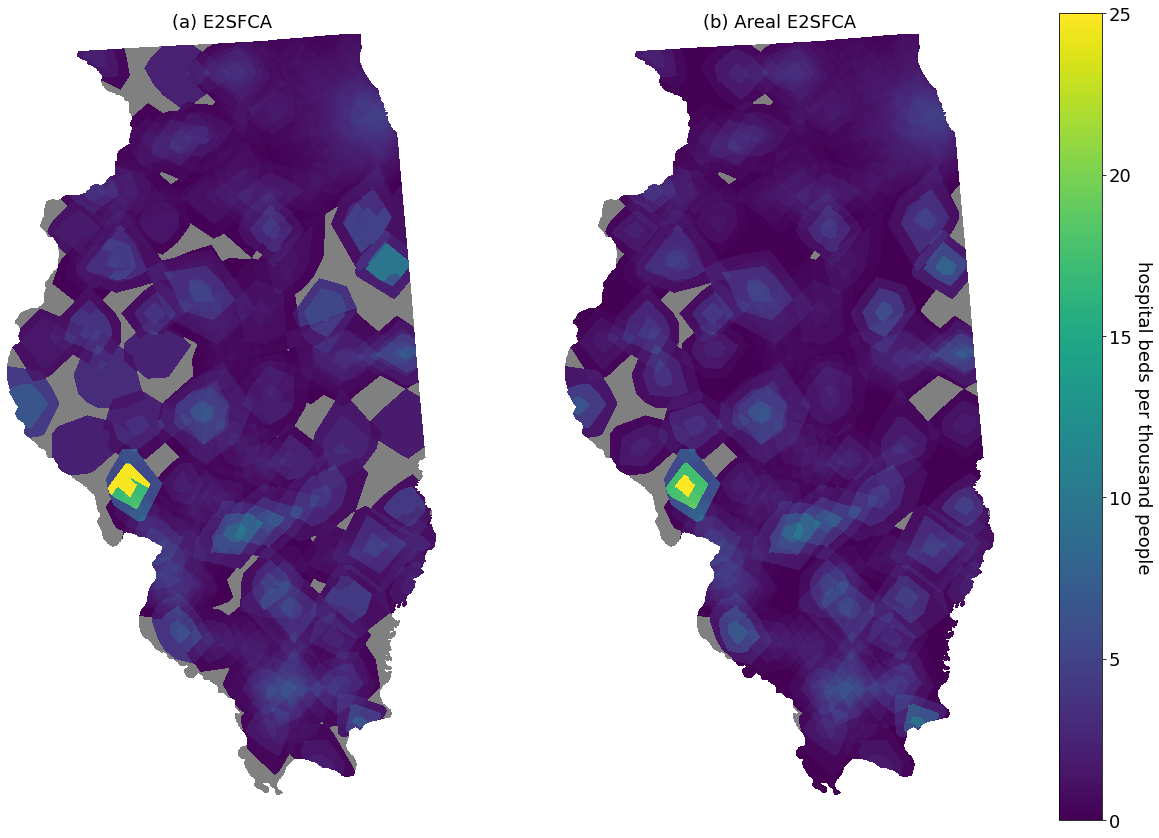

In [54]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=sbssize)
vmin = min(np.nanmin(e2sfca_tract["e2sfca"]), np.nanmin(ae2sfca_tract["ae2sfca"]))
vmax = max(np.nanmax(e2sfca_tract["e2sfca"]), np.nanmax(ae2sfca_tract["ae2sfca"]))
tick_spacing = round(int(vmax - vmin) / (integer_ticks - 1))
ticks = list(range(math.floor(vmin), math.ceil(vmax) + 1, tick_spacing))
vmin, vmax = min(ticks), max(ticks)
axes[0] = e2sfca_tract.plot(column="e2sfca", ax=axes[0], antialiased=False, cmap=cmap,
                             edgecolor="none", missing_kwds=dict(color=nullcolor),
                             vmin=vmin, vmax=vmax)
axes[0].set_title("(a) E2SFCA", fontsize=cbarfont)
axes[1] = ae2sfca_tract.plot(column="ae2sfca", ax=axes[1], antialiased=False, cmap=cmap,
                              edgecolor="none", missing_kwds=dict(color=nullcolor),
                              vmin=vmin, vmax=vmax)
axes[1].set_title("(b) Areal E2SFCA", fontsize=cbarfont)

# add colorbar axes
plt.subplots_adjust(wspace=0, hspace=0)
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.9, 0.1, 0.03, 0.8])
cax.tick_params(labelsize=cbarfont)
# create colormap
colorbarsm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
colorbarsm._A = []
# convert ticks to integers
colorbar = fig.colorbar(colorbarsm, cax=cax, ticks=ticks)
ticklabels = [str(tick) for tick in ticks]
# add >= or <= if necessary
if ticks[0] > vmin:
    ticklabels[0] = r"$\leq${}".format(ticklabels[0])
if ticks[-1] < vmax:
    ticklabels[-1] = r"$\geq${}".format(ticklabels[-1])
colorbar.ax.set_yticklabels(ticklabels)
colorbar.set_label(colorbar_text, fontsize=cbarfont, labelpad=20, rotation=270)
for ax in axes:
    ax.margins(x=0, y=0)
    ax.set_axis_off()
path = os.path.join(figpath, "IL-tract-ttpolygons.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Areal E2SFCA')

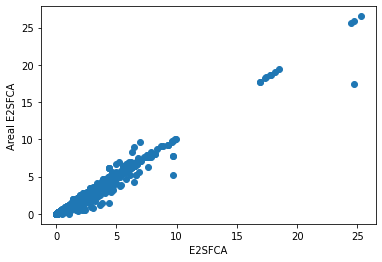

In [55]:
# 0 is left as nan for plotting purposes, but for scatter, we want to fill it in
e2sfca_tract["e2sfca"] = e2sfca_tract["e2sfca"].fillna(value=0)
ae2sfca_tract["ae2sfca"] = ae2sfca_tract["ae2sfca"].fillna(value=0)
plt.scatter(e2sfca_tract["e2sfca"], ae2sfca_tract["ae2sfca"])
plt.xlabel("E2SFCA")
plt.ylabel("Areal E2SFCA")

In [56]:
r, p = pearsonr(e2sfca_tract["e2sfca"], ae2sfca_tract["ae2sfca"])
print(f"The Pearon's R is {r:0.3f} with a two-tailed p-value of {p}")

The Pearon's R is 0.997 with a two-tailed p-value of 0.0


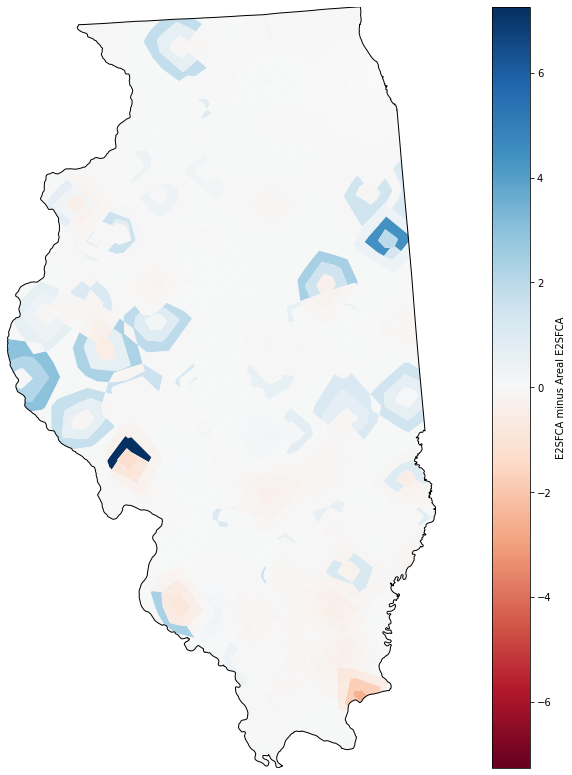

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=sbssize)
tract_diff = agg_gdf.copy(deep=True)
tract_diff["diff"] = np.asarray(e2sfca_tract["e2sfca"]) - np.asarray(ae2sfca_tract["ae2sfca"])
_min, _max = np.nanmin(tract_diff["diff"]), np.nanmax(tract_diff["diff"])
# get 'largest' value by absolute value to center our legend around zero
max_mag = max(abs(_min), abs(_max))
ax = tract_diff.plot(ax=ax, column="diff", figsize=ilfigsize, legend=True, cmap=comparecmap,
                    vmin=-max_mag, vmax=max_mag,
                    legend_kwds={'label': diff_colorbar_text})
ax = il.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.margins(x=0, y=0)
ax.set_axis_off()
path = os.path.join(figpath, "IL-tract-diff-ttpoly.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

<hr id="tract"/>

# Block Group

Now we can grab the population data at the block group level!

In [58]:
group_pop = gpd.read_file("../data/population/IL-Group.shp")
group_pop = group_pop.to_crs(projection)
group_pop.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,TOTPOP,geometry
0,17,031,063303,2,1500000US170310633032,170310633032,2,BG,84097,0,705.0,"POLYGON ((687667.935 527058.112, 687835.053 52..."
1,17,031,081202,4,1500000US170310812024,170310812024,4,BG,28863,0,850.0,"POLYGON ((688743.908 523649.975, 689134.835 52..."
2,17,097,864410,3,1500000US170978644103,170978644103,3,BG,1654247,34701,657.0,"POLYGON ((649394.338 551263.733, 649366.637 55..."
3,17,031,242000,3,1500000US170312420003,170312420003,3,BG,79671,0,963.0,"POLYGON ((685552.767 523387.442, 685635.534 52..."
4,17,031,824113,2,1500000US170318241132,170318241132,2,BG,2526191,46821,1367.0,"POLYGON ((668128.972 491112.276, 669706.091 49..."


Let's plot the population per county:

<AxesSubplot:>

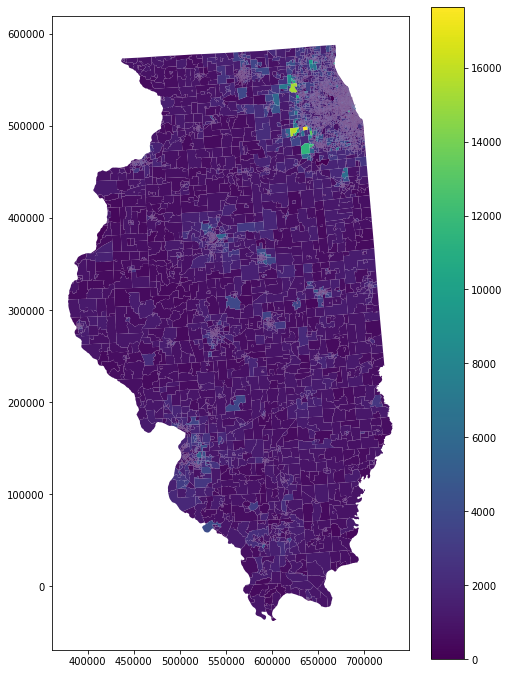

In [59]:
group_pop.plot(column="TOTPOP", figsize=ilfigsize, legend=True)

Now let's calculate and plot E2SFCA:

In [60]:
e2sfca_group = e2sfca(catchments,
                       "e2sfca",
                       catchment_id, 
                       group_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
e2sfca_group["e2sfca"] = e2sfca_group["e2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [02:11<00:00, 43.73s/it]


In [61]:
e2sfca_group.to_file(os.path.join(output_path, "e2sfca-group-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


<AxesSubplot:>

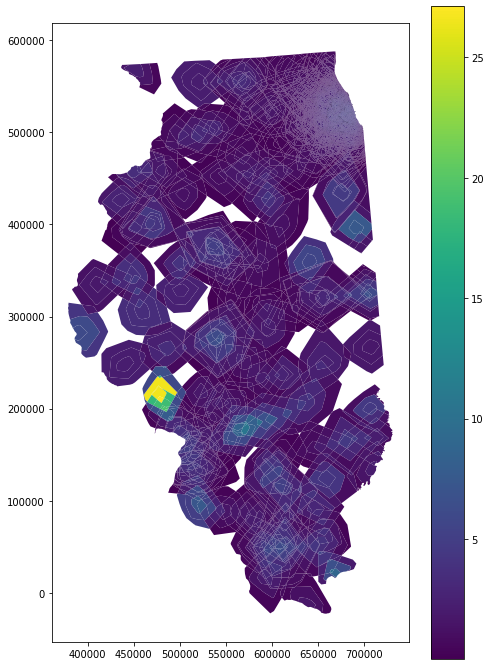

In [62]:
e2sfca_group.plot(column="e2sfca", figsize=ilfigsize, legend=True)

In [63]:
ae2sfca_group = ae2sfca(catchments,
                       "ae2sfca",
                       catchment_id, 
                       group_pop,
                       "GEOID",
                       "TOTPOP",
                       resource,
                       agg_gdf,
                       "id",
                       distances,
                       weights
                      )
# standardize to beds per thousand people
ae2sfca_group["ae2sfca"] = ae2sfca_group["ae2sfca"] * 1000

Calculating Intersections: 100%|██████████| 3/3 [04:25<00:00, 88.37s/it]


In [64]:
ae2sfca_county.to_file(os.path.join(output_path, "ae2sfca-group-ttpoly.shp"))

/home/dijkstra/.local/lib/python3.8/site-packages/geopandas/io/file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


Similarly, we can calculate the Areal E2SFCA and plot it:

<AxesSubplot:>

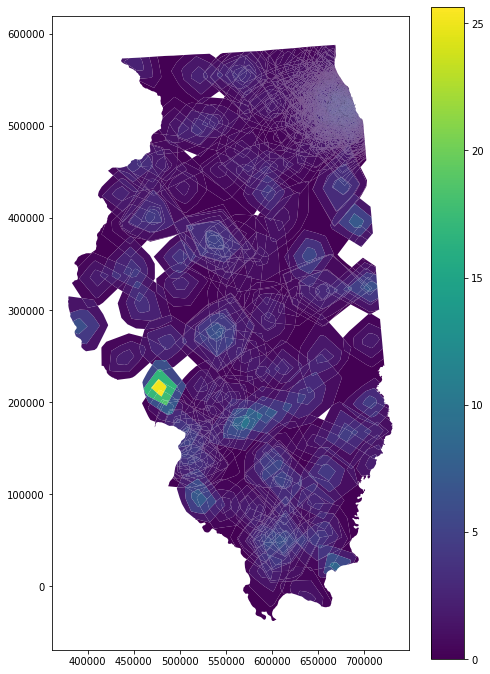

In [65]:
ae2sfca_group.plot(column="ae2sfca", figsize=ilfigsize, legend=True)

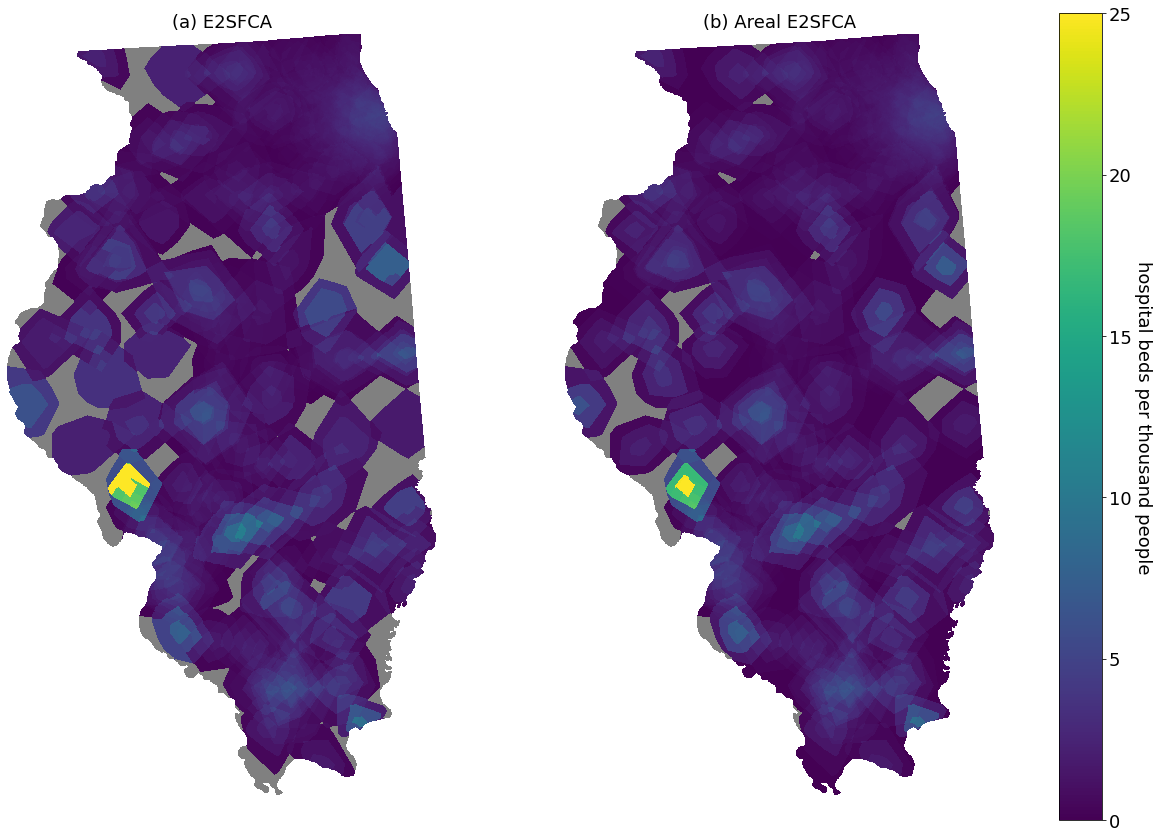

In [66]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=sbssize)
vmin = min(np.nanmin(e2sfca_group["e2sfca"]), np.nanmin(ae2sfca_group["ae2sfca"]))
vmax = max(np.nanmax(e2sfca_group["e2sfca"]), np.nanmax(ae2sfca_group["ae2sfca"]))
tick_spacing = round(int(vmax - vmin) / (integer_ticks - 1))
ticks = list(range(math.floor(vmin), math.ceil(vmax) + 1, tick_spacing))
vmin, vmax = min(ticks), max(ticks)
axes[0] = e2sfca_group.plot(column="e2sfca", ax=axes[0], antialiased=False, cmap=cmap,
                             edgecolor="none", missing_kwds=dict(color=nullcolor),
                             vmin=vmin, vmax=vmax)
axes[0].set_title("(a) E2SFCA", fontsize=cbarfont)
axes[1] = ae2sfca_group.plot(column="ae2sfca", ax=axes[1], antialiased=False, cmap=cmap,
                              edgecolor="none", missing_kwds=dict(color=nullcolor),
                              vmin=vmin, vmax=vmax)
axes[1].set_title("(b) Areal E2SFCA", fontsize=cbarfont)

# add colorbar axes
plt.subplots_adjust(wspace=0, hspace=0)
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.9, 0.1, 0.03, 0.8])
cax.tick_params(labelsize=cbarfont)
# create colormap
colorbarsm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
colorbarsm._A = []
# convert ticks to integers
colorbar = fig.colorbar(colorbarsm, cax=cax, ticks=ticks)
ticklabels = [str(tick) for tick in ticks]
# add >= or <= if necessary
if ticks[0] > vmin:
    ticklabels[0] = r"$\leq${}".format(ticklabels[0])
if ticks[-1] < vmax:
    ticklabels[-1] = r"$\geq${}".format(ticklabels[-1])
colorbar.ax.set_yticklabels(ticklabels)
colorbar.set_label(colorbar_text, fontsize=cbarfont, labelpad=20, rotation=270)
for ax in axes:
    ax.margins(x=0, y=0)
    ax.set_axis_off()
path = os.path.join(figpath, "IL-group-ttpolygons.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Areal E2SFCA')

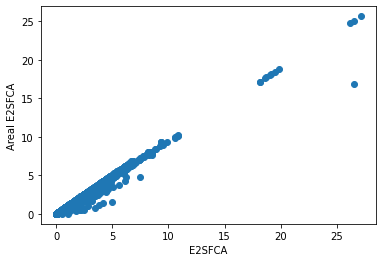

In [67]:
# 0 is left as nan for plotting purposes, but for scatter, we want to fill it in
e2sfca_group["e2sfca"] = e2sfca_group["e2sfca"].fillna(value=0)
ae2sfca_group["ae2sfca"] = ae2sfca_group["ae2sfca"].fillna(value=0)
plt.scatter(e2sfca_group["e2sfca"], ae2sfca_group["ae2sfca"])
plt.xlabel("E2SFCA")
plt.ylabel("Areal E2SFCA")

In [68]:
r, p = pearsonr(e2sfca_group["e2sfca"], ae2sfca_group["ae2sfca"])
print(f"The Pearon's R is {r:0.3f} with a two-tailed p-value of {p}")

The Pearon's R is 0.997 with a two-tailed p-value of 0.0


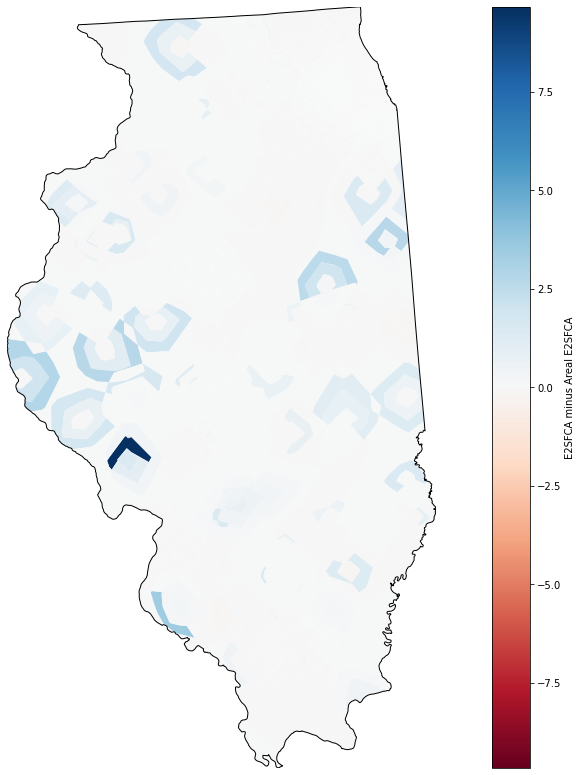

In [69]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=sbssize)
group_diff = agg_gdf.copy(deep=True)
group_diff["diff"] = np.asarray(e2sfca_group["e2sfca"]) - np.asarray(ae2sfca_group["ae2sfca"])
_min, _max = np.nanmin(group_diff["diff"]), np.nanmax(group_diff["diff"])
# get 'largest' value by absolute value to center our legend around zero
max_mag = max(abs(_min), abs(_max))
ax = group_diff.plot(ax=ax, column="diff", figsize=ilfigsize, legend=True, cmap=comparecmap,
                    vmin=-max_mag, vmax=max_mag,
                    legend_kwds={'label': diff_colorbar_text})
ax = il.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.margins(x=0, y=0)
ax.set_axis_off()
path = os.path.join(figpath, "IL-group-diff-ttpoly.jpeg")
plt.savefig(path, dpi=pltdpi, bbox_inches='tight')
plt.show()